In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from node2vec import Node2Vec

/home/yro/graphml-lab/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from graphlab.graph import build_graph_split, build_graph
from graphlab.data import load_and_split_features
from graphlab.models import build_rf_baseline
from graphlab.evaluation import evaluate_binary_classifier

In [3]:
G = build_graph("../data/txs_edgelist.csv", "../data/txs_features.csv", "../data/txs_classes.csv")
G_train, G_val, G_test = build_graph_split("../data/txs_edgelist.csv", "../data/txs_features.csv", "../data/txs_classes.csv")

In [4]:
node2vec = Node2Vec(
    G,
    dimensions=64,
    walk_length=30,
    num_walks=10,
    p=1.0,
    q=1.0,
    workers=4,
    seed=42,
)

Generating walks (CPU: 4): 100%|██████████| 2/2 [00:03<00:00,  1.57s/it]


In [5]:
model = node2vec.fit(
    window=10,
    min_count=1,
    batch_words=4,
)

In [6]:
def get_embeddings(model, nodes):
    embeddings = []

    for node in nodes:
        if str(node) in model.wv:
            embeddings.append(
                {
                    "txId": node,
                    "embedding": model.wv[str(node)],
                }
            )

    return pd.DataFrame(embeddings)

In [7]:
embeddings_df = get_embeddings(
    model,
    G_train.nodes()
)

In [8]:
embeddings_df.head()

,txId,embedding
0,232022460,"[1.2794849, -0.079164185, -0.4371705, -0.73957..."
1,232438397,"[2.9478457, -0.25593594, -1.4348465, -1.448019..."
2,232013274,"[0.28113025, 0.21005414, -0.22461484, 0.011433..."
3,232029206,"[1.28301, 1.3644525, -0.9831724, 0.025371417, ..."
4,232344069,"[0.6013069, 0.16185993, -0.39594615, -0.212327..."


In [9]:
embeddings_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54901 entries, 0 to 54900
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   txId       54901 non-null  int64 
 1   embedding  54901 non-null  object
dtypes: int64(1), object(1)
memory usage: 858.0+ KB


In [10]:
X_train_graph, y_train_graph, X_val_graph, y_val_graph, X_test_graph, y_test_graph = load_and_split_features("../data/txs_features.csv", "../data/txs_classes.csv", txId=True, compute=True, G=G)
X_train, y_train, X_val, y_val, X_test, y_test = load_and_split_features("../data/txs_features.csv", "../data/txs_classes.csv", txId=True)

/home/yro/graphml-lab/src/graphlab/data.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.insert(loc=2, column='class', value=df_classes['class'])
/home/yro/graphml-lab/src/graphlab/features.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['in_degree'] = df['txId'].map(in_degree)
/home/yro/graphml-lab/src/graphlab/features.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using 

In [11]:
X_train.head()

,txId,Time step,Local_feature_1,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,...,in_BTC_min,in_BTC_max,in_BTC_mean,in_BTC_median,in_BTC_total,out_BTC_min,out_BTC_max,out_BTC_mean,out_BTC_median,out_BTC_total
3,68869,1,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,-0.161652,...,0.308900,8.000000,3.102967,1.000000,9.308900,1.229000e+00,8.079800,4.654400,4.654400,9.308800
4,89273,1,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,5.335864,...,852.164680,852.164680,852.164680,852.164680,852.164680,1.300000e-07,41.264036,0.065016,0.000441,852.164680
11,293323,1,-0.172726,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.163383,...,0.040774,0.040774,0.040774,0.040774,0.040774,9.480000e-04,0.039726,0.020337,0.020337,0.040674
22,1494462,1,-0.172921,-0.158783,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.163581,...,0.010000,0.010000,0.010000,0.010000,0.010000,2.900000e-03,0.006900,0.004900,0.004900,0.009800
25,1582950,1,-0.169967,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160559,...,0.478277,0.478277,0.478277,0.478277,0.478277,4.630000e-02,0.431877,0.239088,0.239088,0.478177


In [12]:
X_train.shape

(26750, 184)

In [13]:
train_nodes = set(X_train['txId'])

embeddings_df = embeddings_df[embeddings_df['txId'].isin(train_nodes)]

X_embeddings = np.array(list(embeddings_df['embedding']))

X_train = np.hstack([X_train, X_embeddings])

Drop txId column

In [14]:
X_train = X_train[:, 1:]

In [15]:
X_train.shape

(26750, 247)

In [16]:
rf_model = build_rf_baseline()

In [17]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[1,2]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,247
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on

In [18]:
X_train_graph.head()

,txId,Time step,Local_feature_1,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,...,out_BTC_mean,out_BTC_median,out_BTC_total,in_degree,out_degree,total_degree,pagerank,neighbors_1hop,neighbors_2hop,clustering
3,68869,1,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,-0.161652,...,4.654400,4.654400,9.308800,0,1,1,0.000002,1,2,0.0000
4,89273,1,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,5.335864,...,0.065016,0.000441,852.164680,1,288,289,0.000002,289,490,0.0003
11,293323,1,-0.172726,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.163383,...,0.020337,0.020337,0.040674,1,1,2,0.000003,2,7,0.0000
22,1494462,1,-0.172921,-0.158783,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.163581,...,0.004900,0.004900,0.009800,1,0,1,0.000008,1,2,0.0000
25,1582950,1,-0.169967,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160559,...,0.239088,0.239088,0.478177,1,0,1,0.000003,1,1,0.0000


In [19]:
X_train_graph.shape

(26750, 191)

In [20]:
X_train_graph = np.hstack([X_train_graph, X_embeddings])

In [21]:
X_train_graph = X_train_graph[:, 1:]

In [22]:
X_train_graph.shape

(26750, 254)

In [23]:
rf_model_graph = build_rf_baseline()

In [24]:
rf_model_graph.fit(
    X_train_graph,
    y_train_graph,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[1,2]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,254
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on

In [25]:
val_embeddings_df = get_embeddings(
    model,
    G_val.nodes
)

In [26]:
val_nodes = set(X_val['txId'])

val_embeddings_df = val_embeddings_df[val_embeddings_df['txId'].isin(val_nodes)]

X_val_embeddings = np.array(list(val_embeddings_df['embedding']))

X_val = np.hstack([X_val, X_val_embeddings])
X_val_graph = np.hstack([X_val_graph, X_val_embeddings])

In [27]:
X_val = X_val[:, 1:]
X_val_graph = X_val_graph[:, 1:]

In [28]:
val_result_rf = evaluate_binary_classifier(rf_model, X_val, y_val)
val_result_rf_graph = evaluate_binary_classifier(rf_model_graph, X_val_graph, y_val_graph)

In [29]:
print("Validation Random Forest Classifier Node2vec")
print(val_result_rf["classification_report"])

Validation Random Forest Classifier Node2vec
              precision    recall  f1-score   support

           1       0.98      0.97      0.97       690
           2       0.99      1.00      0.99      3591

    accuracy                           0.99      4281
   macro avg       0.99      0.98      0.98      4281
weighted avg       0.99      0.99      0.99      4281



In [30]:
print("Validation Random Forest Classifier Node2vec + graph features")
print(val_result_rf_graph["classification_report"])

Validation Random Forest Classifier Node2vec + graph features
              precision    recall  f1-score   support

           1       0.98      0.97      0.97       690
           2       0.99      1.00      0.99      3591

    accuracy                           0.99      4281
   macro avg       0.99      0.98      0.98      4281
weighted avg       0.99      0.99      0.99      4281



In [31]:
results_table = pd.DataFrame({
    "Model": ["Random Forest", "Random Forest"],
    "Features": ["Node2vec", "Node2vec + graph features"],
    "PR-AUC": [
        val_result_rf["pr_auc"],
        val_result_rf_graph["pr_auc"]
    ],
    "ROC-AUC": [
        val_result_rf["roc_auc"],
        val_result_rf_graph["roc_auc"]
    ]
})

results_table

,Model,Features,PR-AUC,ROC-AUC
0,Random Forest,Node2vec,0.089324,0.997075
1,Random Forest,Node2vec + graph features,0.087912,0.997138


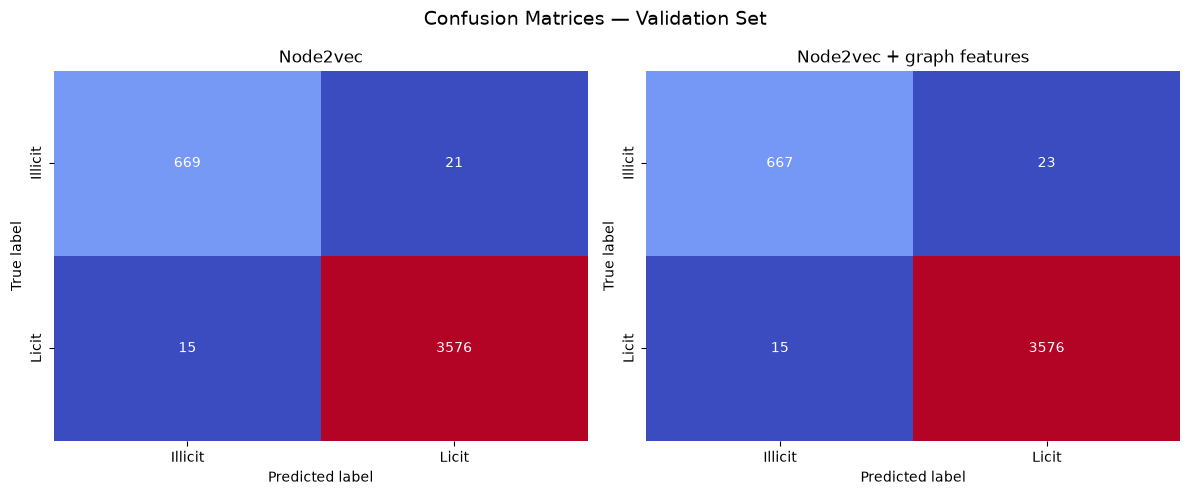

In [32]:
cm = val_result_rf["confusion_matrix"]
cm_graph = val_result_rf_graph["confusion_matrix"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=["Illicit", "Licit"],
    yticklabels=["Illicit", "Licit"],
    cbar=False,
    ax=axes[0],
)

axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
axes[0].set_title("Node2vec")

sns.heatmap(
    cm_graph,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=["Illicit", "Licit"],
    yticklabels=["Illicit", "Licit"],
    cbar=False,
    ax=axes[1],
)

axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")
axes[1].set_title("Node2vec + graph features")

plt.suptitle("Confusion Matrices — Validation Set", fontsize=14)
plt.tight_layout()
plt.show()

In [33]:
test_embeddings_df = get_embeddings(
    model,
    G_test.nodes
)

In [36]:
test_nodes = set(X_test['txId'])

test_embeddings_df = test_embeddings_df[test_embeddings_df['txId'].isin(test_nodes)]

X_test_embeddings = np.array(list(test_embeddings_df['embedding']))

X_test = np.hstack([X_test, X_test_embeddings])
X_test_graph = np.hstack([X_test_graph, X_test_embeddings])

In [37]:
X_test = X_test[:, 1:]
X_test_graph = X_test_graph[:, 1:]

In [38]:
test_result_rf = evaluate_binary_classifier(rf_model, X_test, y_test)
test_result_rf_graph = evaluate_binary_classifier(rf_model_graph, X_test_graph, y_test_graph)

In [39]:
print("Test Random Forest Classifier Node2vec")
print(test_result_rf["classification_report"])

Test Random Forest Classifier Node2vec
              precision    recall  f1-score   support

           1       0.91      0.66      0.77       901
           2       0.98      1.00      0.99     14113

    accuracy                           0.98     15014
   macro avg       0.95      0.83      0.88     15014
weighted avg       0.97      0.98      0.97     15014



In [40]:
print("Test Random Forest Classifier Node2vec + graph features")
print(test_result_rf_graph["classification_report"])

Test Random Forest Classifier Node2vec + graph features
              precision    recall  f1-score   support

           1       0.93      0.66      0.77       901
           2       0.98      1.00      0.99     14113

    accuracy                           0.98     15014
   macro avg       0.95      0.83      0.88     15014
weighted avg       0.98      0.98      0.97     15014



In [41]:
results_table = pd.DataFrame({
    "Model": ["Random Forest", "Random Forest"],
    "Features": ["Node2vec", "Node2vec + graph features"],
    "PR-AUC": [
        test_result_rf["pr_auc"],
        test_result_rf_graph["pr_auc"]
    ],
    "ROC-AUC": [
        test_result_rf["roc_auc"],
        test_result_rf_graph["roc_auc"]
    ]
})

results_table

,Model,Features,PR-AUC,ROC-AUC
0,Random Forest,Node2vec,0.031898,0.910511
1,Random Forest,Node2vec + graph features,0.031876,0.908425


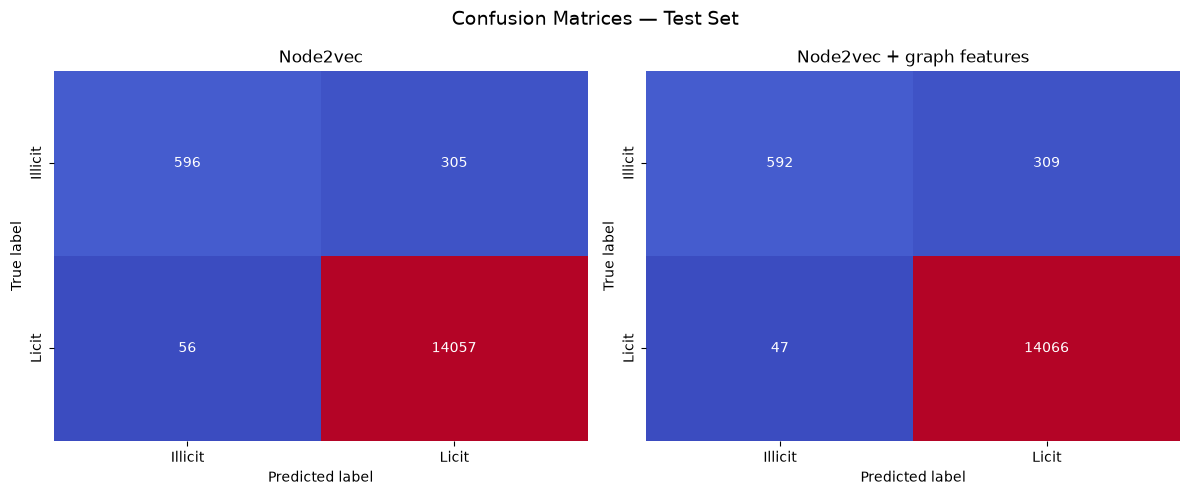

In [42]:
cm = test_result_rf["confusion_matrix"]
cm_graph = test_result_rf_graph["confusion_matrix"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=["Illicit", "Licit"],
    yticklabels=["Illicit", "Licit"],
    cbar=False,
    ax=axes[0],
)

axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
axes[0].set_title("Node2vec")

sns.heatmap(
    cm_graph,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=["Illicit", "Licit"],
    yticklabels=["Illicit", "Licit"],
    cbar=False,
    ax=axes[1],
)

axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")
axes[1].set_title("Node2vec + graph features")

plt.suptitle("Confusion Matrices — Test Set", fontsize=14)
plt.tight_layout()
plt.show()